## Домашнее задание 6
### Полушина Дарья Б06-303
### Отчет

### Часть 1 — Анализ FastQC

В данном задании буду работать со следующими данными:
- /home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R1_001.fastq.gz
- /home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R2_001.fastq.gz

В первой части проведу анализ FastQC и сделаю отчет, используя MultiQC. Скрипт для этого:

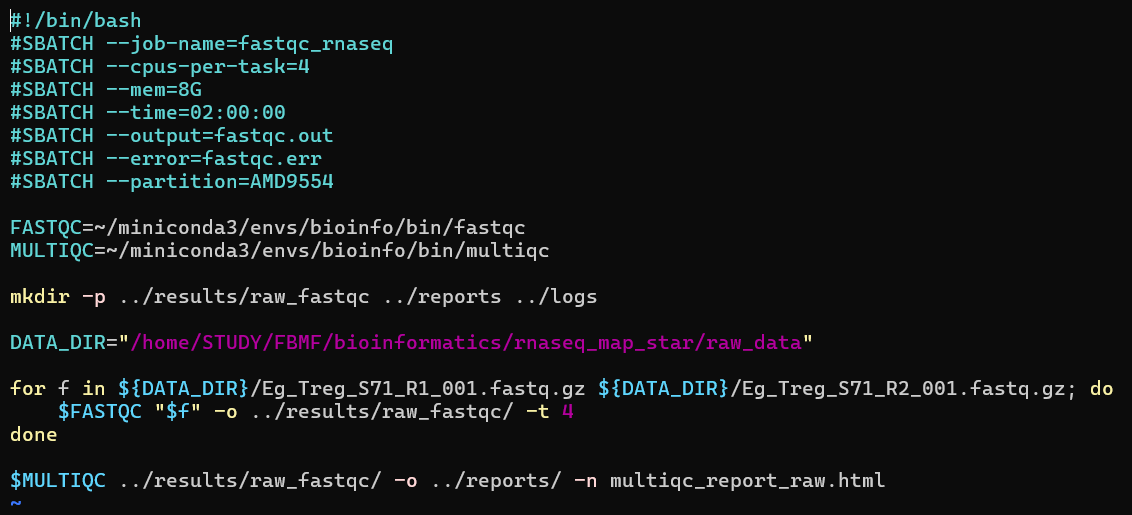

Результаты анализа FastQC лежат в папке `results`: `Eg_Treg_S71_R1_001_fastqc`, `Eg_Treg_S71_R2_001_fastqc`. Отчет MultiQC лежит в папке `reports`: `multiqc_report_raw`.

### Часть 2 — Тримминг

Проанализировав результаты, полученные в первой части, я могу сказать следующее:
1) Да, адаптеры присутствуют, но не в критическом количестве. График Adapter Content показывает очень низкие значения, не превышающие 5%, что не переходит пороговые значения. Ближе к концу уровень растет, но незначительно.
   
   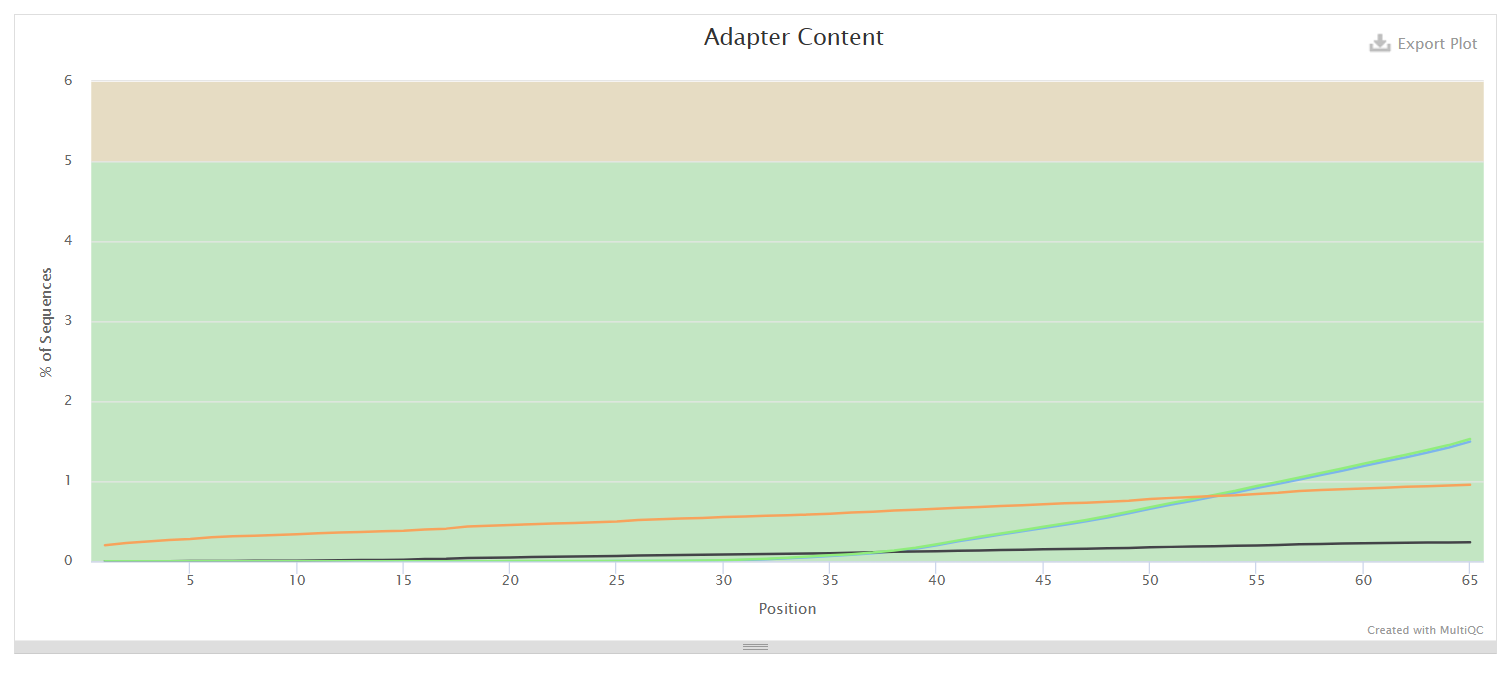
   
3) По отчету MultiQC видно некоторое падение кривой Mean Quality Score в конце. По fastqc уже более четко видно это падение: для данных `Eg_Treg_S71_R2_001.fastq.gz` видно ухудшение качества на 76 цикле, где Q упало ниже 20.
   
   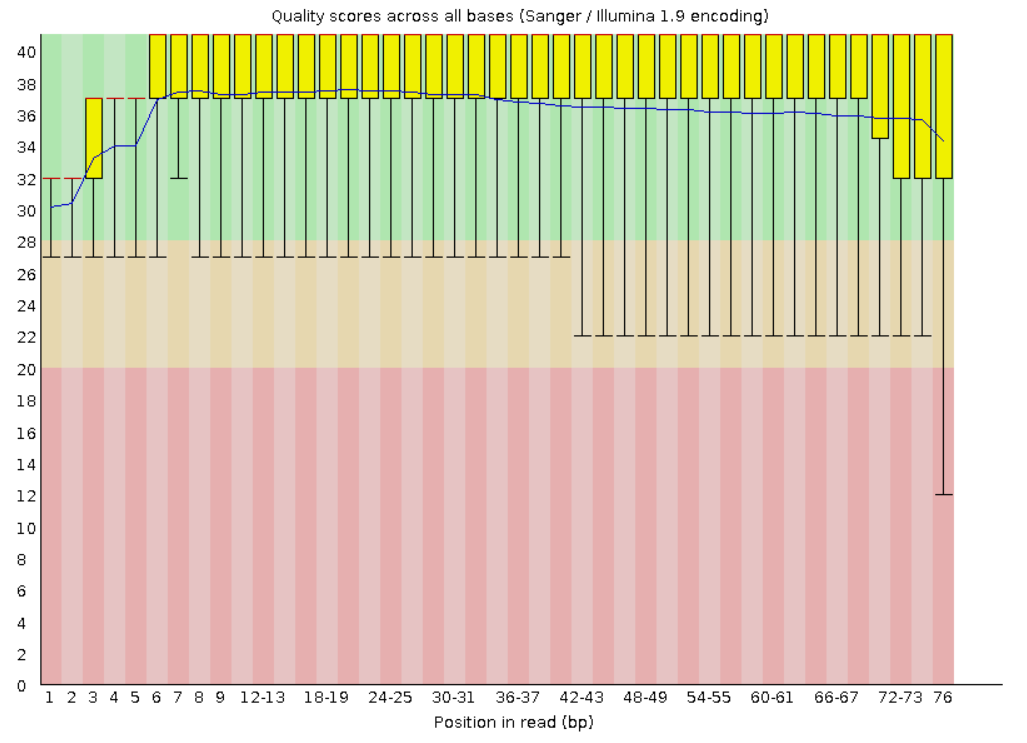

Поскольку к концу чтения качество падает ниже 20, а также есть загрязнение адаптерами, необходим тримминг.

Сделаем тримминг ридов с помощью fastp и анализ качества.

Скрипт для тримминга:

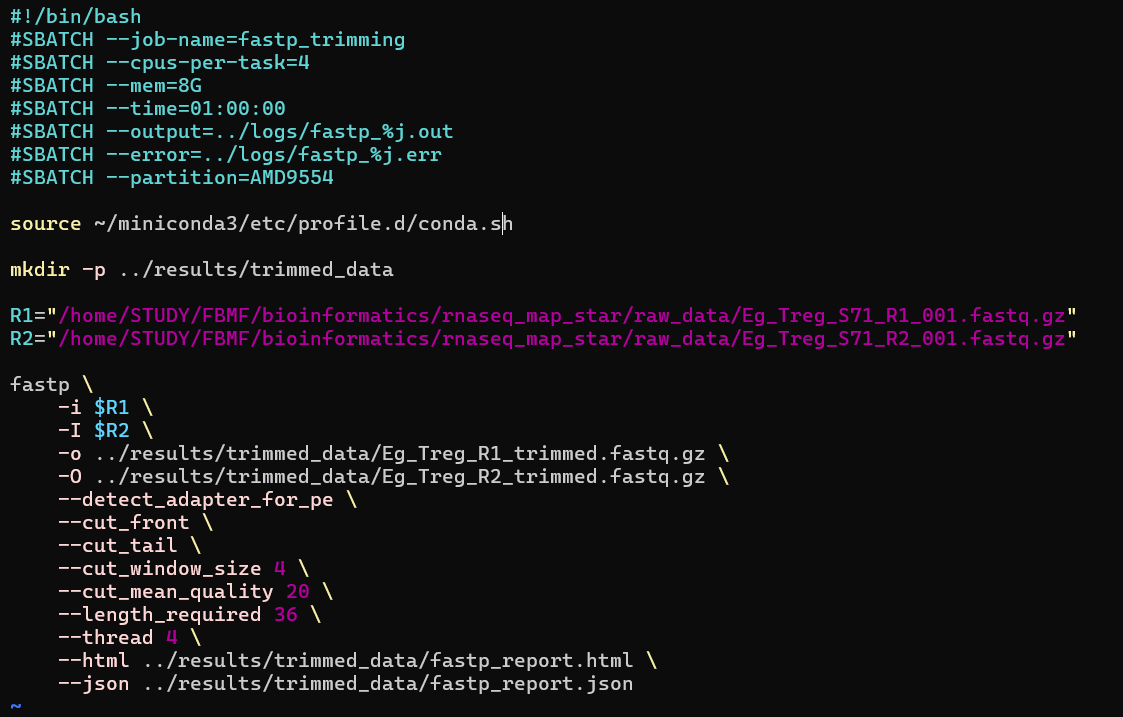

Скрипт для анализа улучшенных данных:

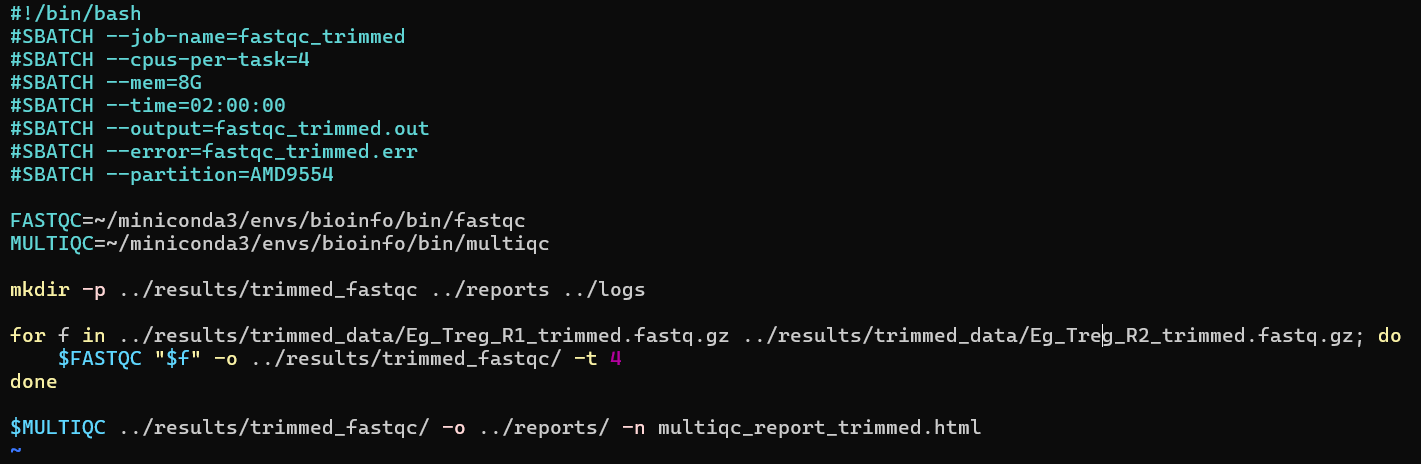

После тримминга уменьшилось число адаптеров. Теперь их число достигает максимум 0,3% (примерно), хотя ранее доходило до 1,5%. Это произошло, так как `--detect_adapter_for_pe` автоматически удалил адаптеры.

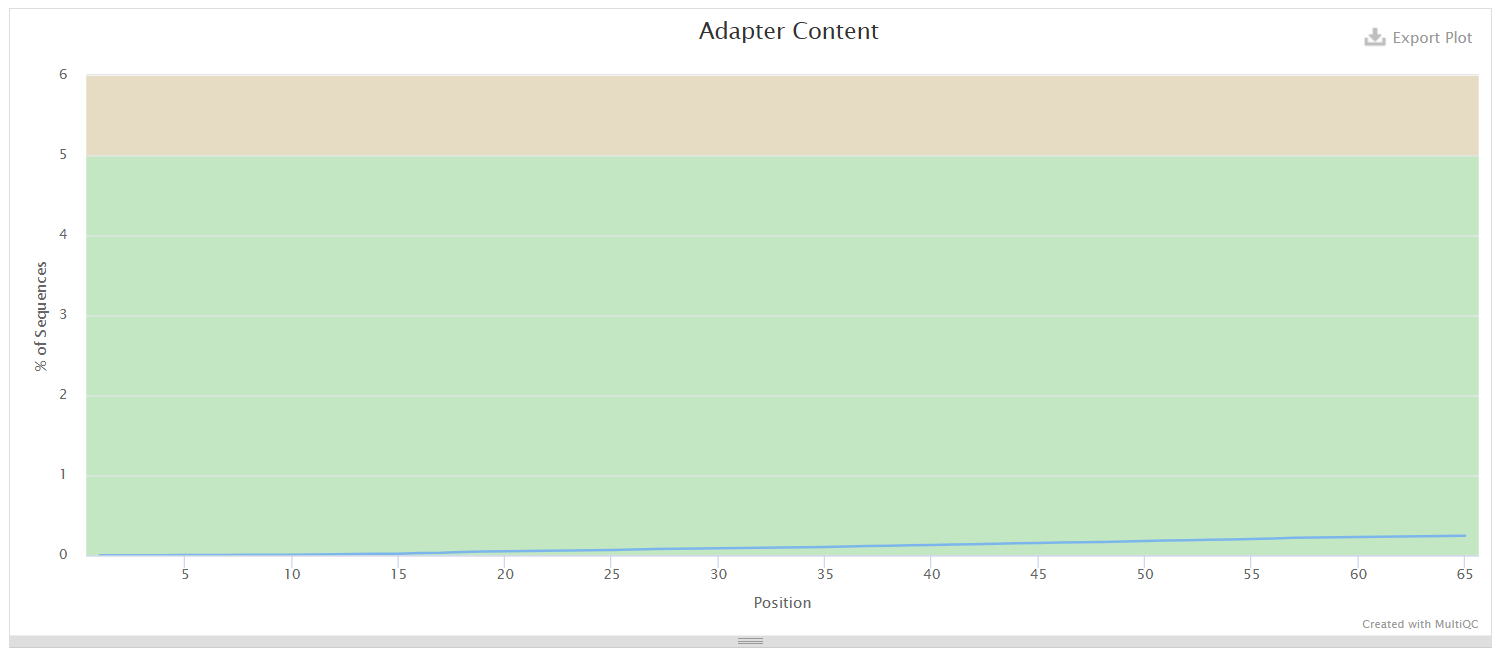

Также после тримминга улучшилось качество в конце ридов. Теперь нет Q<20. Это произошло, так как `--cut_tail` и `--cut_mean_quality 20` обрезали плохие концы.

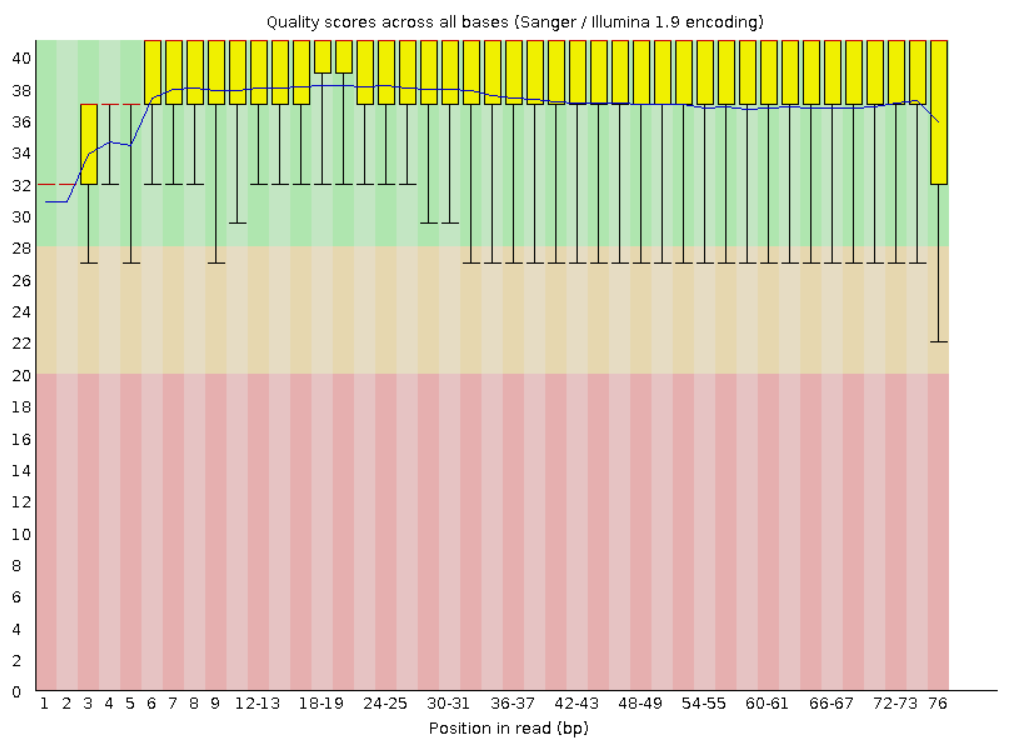

Для выравнивания буду использовать триммированные данные, так как после тримминга я получила:
- улучшенное качество: качество оснований в конце ридов стало выше Q20, что снижает вероятность ошибок при выравнивании;
- удаление адаптеров, которое предотвращает ложное картирование этих последовательностей на геном;

То есть будут более точные подсчеты, что важно для downstream анализа (чтобы каждый прочитанный фрагмент соответствовал реальному транскрипту, а не артефакту библиотеки).

### Часть 3 — Выравнивание на референсный геном — STAR + StringTie

Для следующих шагов устанавливаю через `conda` всё необходимое:
```
conda install -c bioconda star stringtie htseq
```

Далее выровниваю риды на референсный геном /home/STUDY/FBMF/bioinformatics/GRCh38/ с помощью STAR. Выравнивание, как и было написано в части 2, провожу на триммированных данных. Скрипт `star_mapping.slurm` для выравнивания:

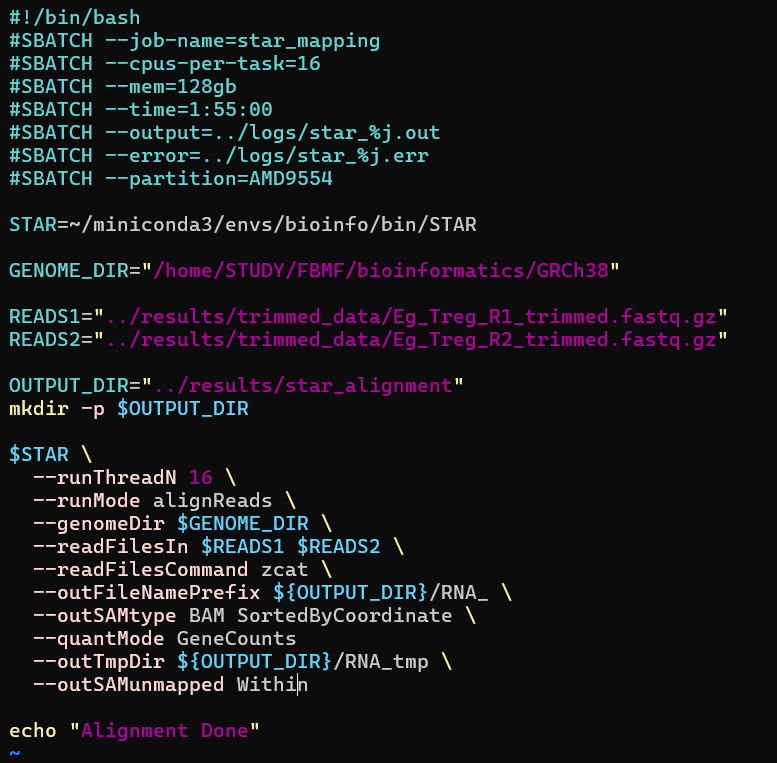

Далее с помощью `StringTie` собираю транскрипты из выравненных ридов (BAM). Запускаю в режиме de novo, чтобы получить собственную модель транскриптов (GTF-файл). Скрипт `stringtie_assemble.slurm`:

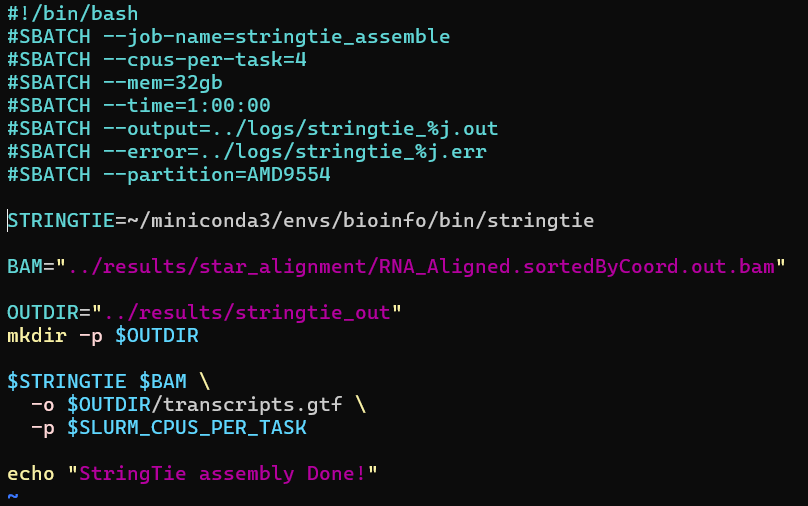

**Результаты:**

Первые 10 строк полученного GTF-файла:

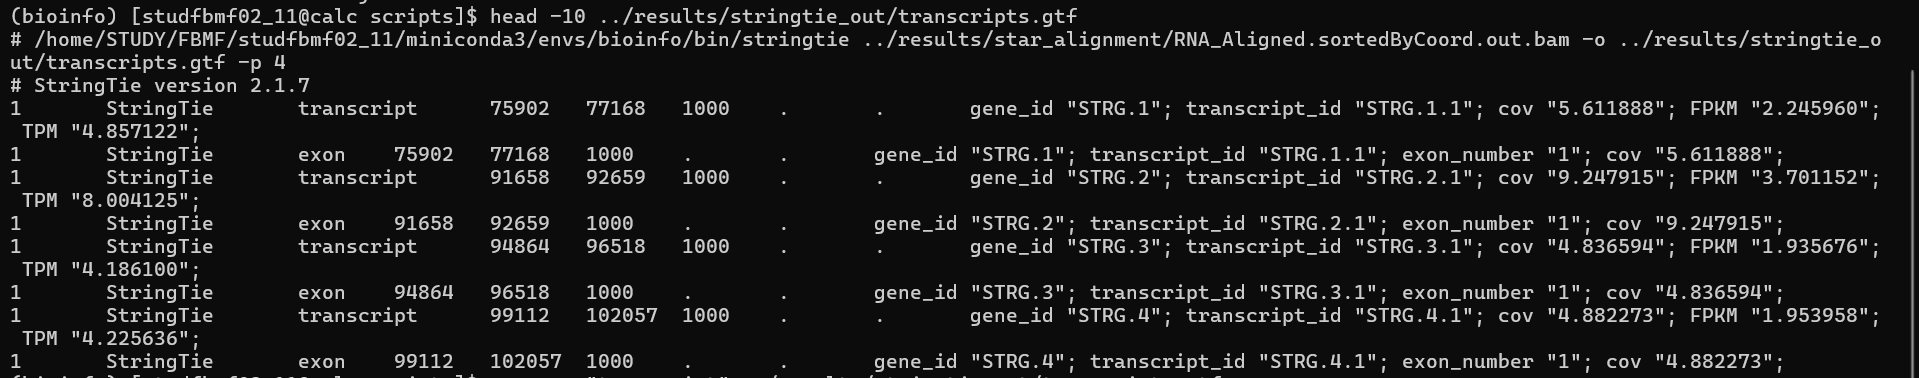

- столбец 1 - номер хромосомы, где находятся транскрипты
- столбец 2 - `StringTie`, то есть используемый метод сборки
- столбец 3 - тип геномного элемента (`transcript` для цеолго транскрипта или `exon` для отдельного экзона внутри транскрипта)
- столбец 4 - координата начала элемента на хромосоме
- столбец 5 - координата конца элемента на хромосоме
- столбец 6 - оценка достоверности (1000 либо .)
- столбец 7 - цепь ДНК (обычно +/-, но у нас не определена, поэтому .)
- столбец 8 - рамка считывания для кодирующих последовательностей (для транскриптов и экзонов .)
- столбец 9 и далее - атрибуты

Таким образом GTF-файл содержит точные координаты (номер хромосомы, начало, конец) для транскриптов, экзонов, а также генов, кодирующих последовательностей, старт- и стоп-кодонов. Каждая строка описывает отдельный элемент (экзон или транскрипт). Причем включается информация - атрибуты. В них могут быть указаны ID гена `gene_id`, которые присваивает StringTie для de novo сборки ("STRG.1", "STRG.2", "STRG.3" и т.д.), ID транскрипта `transcript_id` аналогично ("STRG.1.1" и т.д), номер экзона `exon_number` и покрытие экзона `cov`.

Число транскриптов можно посчитать командой `grep -c $'\ttranscript\t' ../results/stringtie_out/transcripts.gtf`, считая только отдельные слова `transcript`, то есть их количество в 3 столбце.

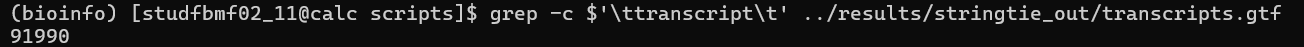

В результате получилось 91990 транскриптов.

Сборка транскриптов StringTie позволяет обнаружить транскрипты, которые могут быть уникальными или новыми для анализируемого образца, а также дать их четкое описание и координаты. Предназначена для количественной оценки экспрессии генов. transcripts.gtf может быть полезен для просмотра структуры транскрипта, оценки сборки, сравнения экспрессии и обнаружения новых транскриптов/изоформ.

### Часть 4 — Выравнивание на референсный геном —HTSeq

В этой части выравниваю риды на референсный геном /home/STUDY/FBMF/bioinformatics/GRCh38/ с помощью HTSeq. Для этого пункта я также создала новое окружение, так как у меня возникли проблемы с библиотекой. в окружение `htseq_env` я установила командой `conda create -n htseq_env -c conda-forge -c bioconda python=3.10 htseq pysam -y` необходимую версию питона и библиотеки. Скрипт для запуска:

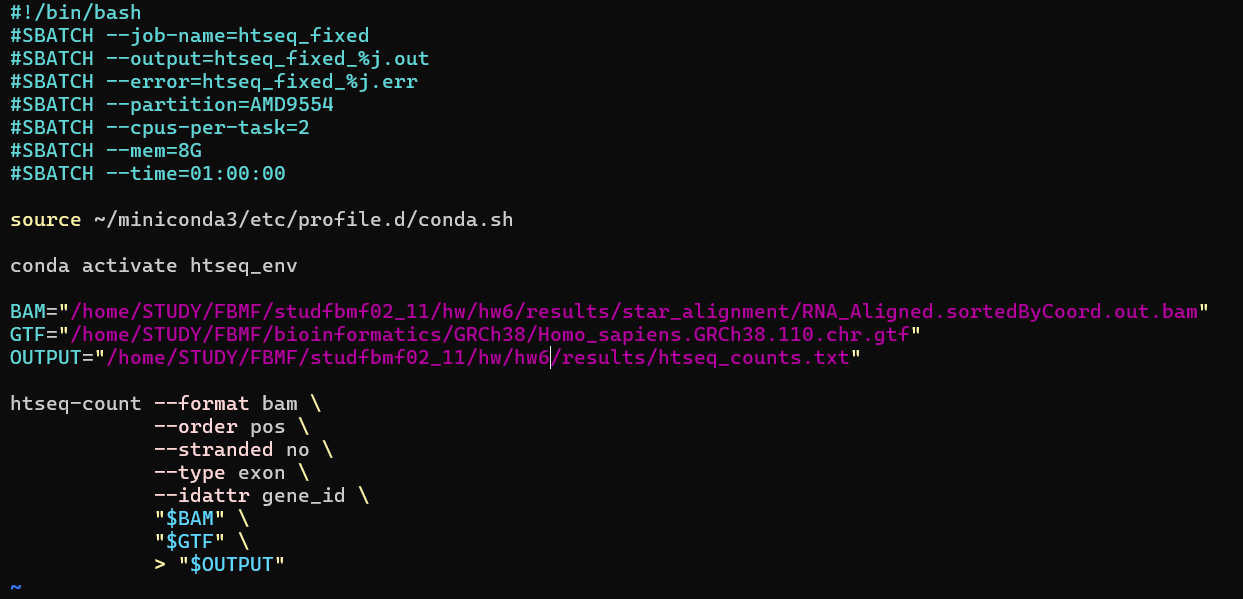

Уникальных генов `htseq_counts.txt` получилось 62700.

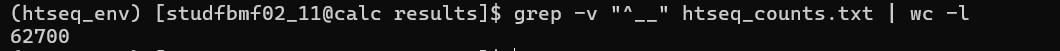

### Результаты:

Скриншот вашей папки с заданием на сервере, со всеми файлами выравнивания

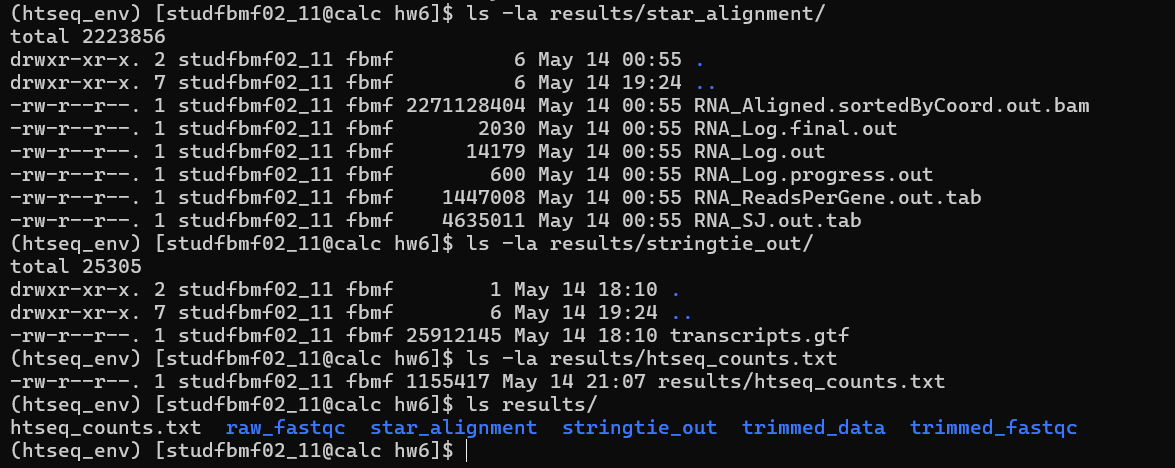

Сравним каунты из STAR (RNA_ReadsPerGene.out.tab, колонка 3) с HTSeq‑count. Для этого строю график, где представлены мои гены: по оси X - STAR, по оси Y — HTSeq counts. Обе оси представлены в логарифмической шкале, y=x - идеальное соответствие, синие точки — каждый ген.

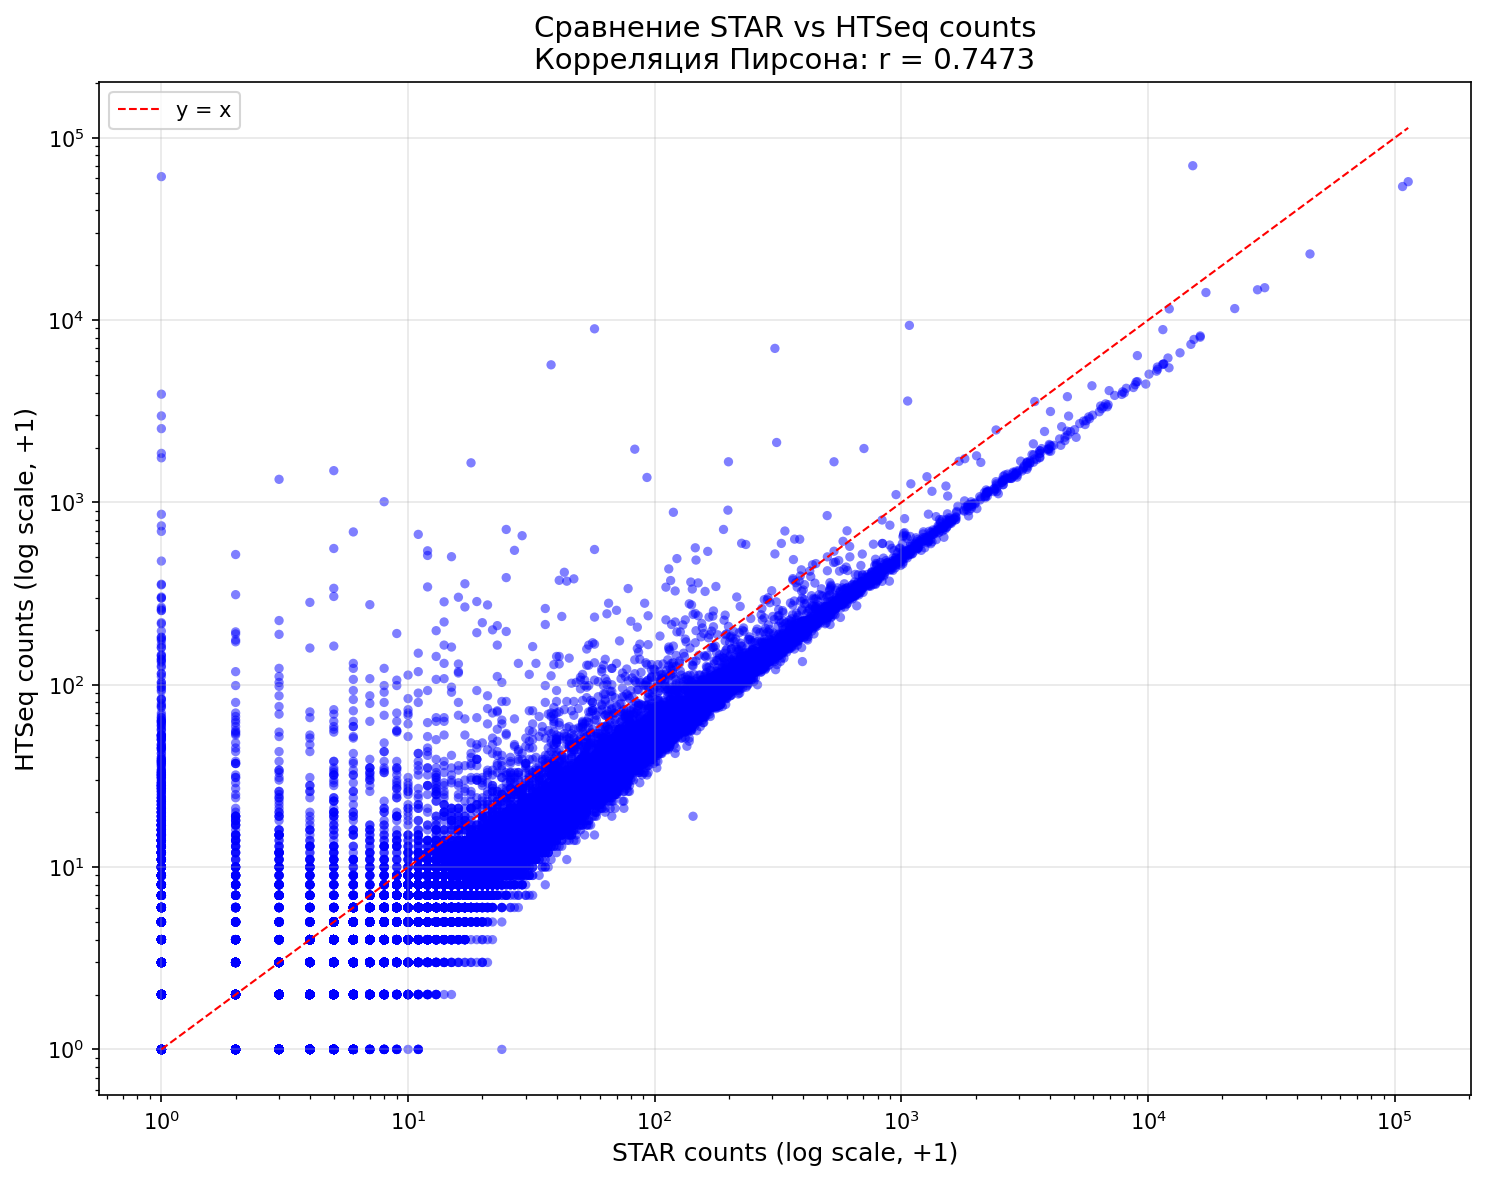

Корреляция равна 0.7473, точки в основном располагаются вдоль прямой x=y, это значит, что мои каунты из STAR и HTSeq‑count в общем согласованы, но не совпадают полностью. В области низкой эксперссии наблюдается наибольший разброс (много точек уходят далеко вверх или вниз от диагонали), это объясняется шумом при низком покрытии. С ростом экспрессии разброс явно уменьшается. Также можно заметить, что точки не совсем на диагонали, а немного ниже ее, смещены в сторону STAR. Это означает, что STAR насчитал больше ридов, чем HTSeq для большинства генов. Это связано с тем, что STAR фильтрует данные не так строго, а HTSeq отбрасывает низкокачественные выравнивания, отсюда он насчитывает меньше ридов.

Для дальнейшего DE‑анализа (DESeq2/edgeR) лучше использовать HTSeq-count. Как было замечено, этот метод фильтрует данные строже, прии этом позволяет оценить долю отброшенных ридов.